## Imports

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [31]:
data_type = 'mean_anom_summer'
defol_2019 = pd.read_csv(f'../data/results_MtPleasant/{data_type}_2019.csv')
defol_2020 = pd.read_csv(f'../data/results_MtPleasant/{data_type}_2020.csv')
defol_2021 = pd.read_csv(f'../data/results_MtPleasant/{data_type}_2021.csv')
defol_2022 = pd.read_csv(f'../data/results_MtPleasant/{data_type}_2022.csv')

## Analysis

In [74]:
def percent_defol(df, upper_cutoff, lower_cutoff):
    mask = (df['stat'] <= lower_cutoff) & (df['stat'] > upper_cutoff)
    return df.loc[mask, 'stat'].count() / df['stat'].count()

print(f'% defoliated in 2019: {percent_defol(defol_2019, -1.0, -0.28)}')
print(f'% defoliated in 2020: {percent_defol(defol_2020, -1.0, -0.28)}')
print(f'% defoliated in 2021: {percent_defol(defol_2021, -1.0, -0.28)}')
print(f'% defoliated in 2022: {percent_defol(defol_2022, -1.0, -0.28)}')

% defoliated in 2019: 0.0
% defoliated in 2020: 0.0
% defoliated in 2021: 0.01134885920321551
% defoliated in 2022: 0.0


In [75]:
dfs = [defol_2019, defol_2020, defol_2021, defol_2022]
severe = [percent_defol(df, -1.0, -0.28)*100 for df in dfs]
moderate = [percent_defol(df, -0.28, -0.18)*100 for df in dfs]
slight = [percent_defol(df, -0.18, -0.08)*100 for df in dfs]
none = [percent_defol(df, -0.08, 1)*100 for df in dfs]

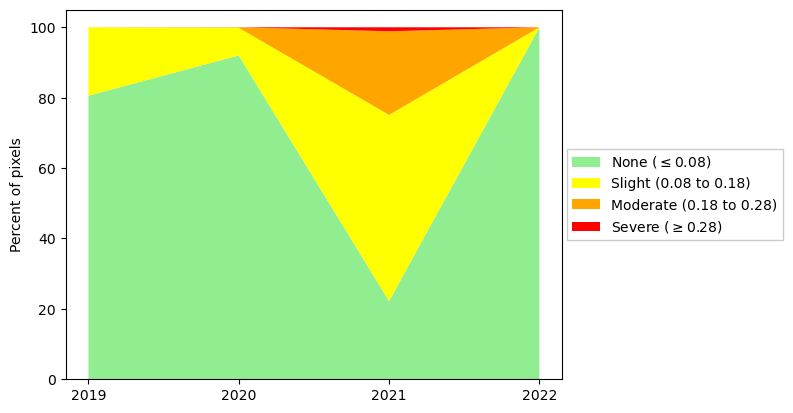

In [140]:
years = [2019, 2020, 2021, 2022]
plt.stackplot(years, none, slight, moderate, severe, labels = [r'None ($\leq$0.08)', 'Slight (0.08 to 0.18)', 'Moderate (0.18 to 0.28)', r'Severe ($\geq$0.28)'], colors = ['lightgreen', 'yellow', 'orange', 'red'])
plt.ylabel('Percent of pixels')
plt.xticks([2019, 2020, 2021, 2022])
plt.legend(loc='center right', bbox_to_anchor=(1.46, 0.5),
          ncol=1, fancybox=False, shadow=False, framealpha = 1.0)
plt.savefig('../data/results_MtPleasant/severity_year.svg', bbox_inches ='tight')

In [84]:
def classify(stat):
    if np.isnan(stat):
        return np.nan
    if (stat > -1.0) and (stat <= -0.28):
        return 3#'Severe'
    elif (stat <= -0.18):
        return 2#'Moderate'
    elif (stat <= -0.08):
        return 1#'Slight'
    else:
        return 0#'None'

defol_2019['class'] = defol_2019['stat'].map(classify)
defol_2020['class'] = defol_2020['stat'].map(classify)
defol_2021['class'] = defol_2021['stat'].map(classify)
defol_2022['class'] = defol_2022['stat'].map(classify)

([], [])

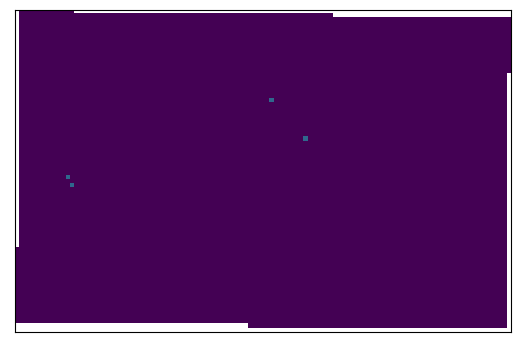

In [85]:
defol_pivot = (defol_2022[['class', 'lat', 'lon']]).pivot(index = 'lat', columns = 'lon')
plt.imshow(defol_pivot, vmin=0, vmax=3)
plt.xticks([])
plt.yticks([])

In [86]:
classes = pd.DataFrame()

classes['2019'] = defol_2019['class']
classes['2020'] = defol_2020['class']
classes['2021'] = defol_2021['class']
classes['2022'] = defol_2022['class']

In [87]:
classes

,2019,2020,2021,2022
0,NaN,NaN,NaN,NaN
1,0.0,1.0,2.0,0.0
2,0.0,1.0,1.0,0.0
3,0.0,1.0,2.0,0.0
4,0.0,1.0,2.0,0.0
...,...,...,...,...
8887,NaN,NaN,NaN,NaN
8888,NaN,NaN,NaN,NaN
8889,NaN,NaN,NaN,NaN
8890,NaN,NaN,NaN,NaN


In [103]:
# Create inter-year change states
def create_state(x,y):
    return f'{x}->{y}'

for i in range(len(classes)):
    classes.at[i, '2019->2020'] = create_state(classes['2019'].iloc[i],classes['2020'].iloc[i])
    classes.at[i, '2020->2021'] = create_state(classes['2020'].iloc[i],classes['2021'].iloc[i])
    classes.at[i, '2021->2022'] = create_state(classes['2021'].iloc[i],classes['2022'].iloc[i])

In [104]:
classes

,2019,2020,2021,2022,2019->2020,2020->2021,2021->2022
0,NaN,NaN,NaN,NaN,nan->nan,nan->nan,nan->nan
1,0.0,1.0,2.0,0.0,0.0->1.0,1.0->2.0,2.0->0.0
2,0.0,1.0,1.0,0.0,0.0->1.0,1.0->1.0,1.0->0.0
3,0.0,1.0,2.0,0.0,0.0->1.0,1.0->2.0,2.0->0.0
4,0.0,1.0,2.0,0.0,0.0->1.0,1.0->2.0,2.0->0.0
...,...,...,...,...,...,...,...
8887,NaN,NaN,NaN,NaN,nan->nan,nan->nan,nan->nan
8888,NaN,NaN,NaN,NaN,nan->nan,nan->nan,nan->nan
8889,NaN,NaN,NaN,NaN,nan->nan,nan->nan,nan->nan
8890,NaN,NaN,NaN,NaN,nan->nan,nan->nan,nan->nan


In [117]:
index = ['0.0->0.0',
         '0.0->1.0',
         '0.0->2.0',
         '0.0->3.0',
         '1.0->0.0',
         '1.0->1.0',
         '1.0->2.0',
         '1.0->3.0',
         '2.0->0.0',
         '2.0->1.0',
         '2.0->2.0',
         '2.0->3.0',
         '3.0->0.0',
         '3.0->1.0',
         '3.0->2.0',
         '3.0->3.0',
         'nan->nan']

transition = pd.DataFrame(0,index=index, columns=index)

for i in range(len(classes)):
    transition.loc[classes.at[i, '2020->2021'], classes.at[i, '2019->2020']] += 1
    transition.loc[classes.at[i, '2021->2022'], classes.at[i, '2020->2021']] += 1
transition

,0.0->0.0,0.0->1.0,0.0->2.0,0.0->3.0,1.0->0.0,1.0->1.0,1.0->2.0,1.0->3.0,2.0->0.0,2.0->1.0,2.0->2.0,2.0->3.0,3.0->0.0,3.0->1.0,3.0->2.0,3.0->3.0,nan->nan
0.0->0.0,3108,0,0,0,485,0,0,0,2,0,0,0,0,0,0,0,0
0.0->1.0,3266,0,0,0,801,0,0,0,2,0,0,0,0,0,0,0,0
0.0->2.0,1513,0,0,0,394,0,0,0,0,0,0,0,0,0,0,0,0
0.0->3.0,77,0,0,0,14,0,0,0,0,0,0,0,0,0,0,0,0
1.0->0.0,0,4200,0,0,0,428,0,0,0,8,0,0,0,0,0,0,0
1.0->1.0,0,337,0,0,0,59,0,0,0,0,0,0,0,0,0,0,0
1.0->2.0,0,83,0,0,0,16,0,0,0,0,0,0,0,0,0,0,0
1.0->3.0,0,2,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0
2.0->0.0,0,0,1905,0,0,0,99,0,0,0,4,0,0,0,0,0,0
2.0->1.0,0,0,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0


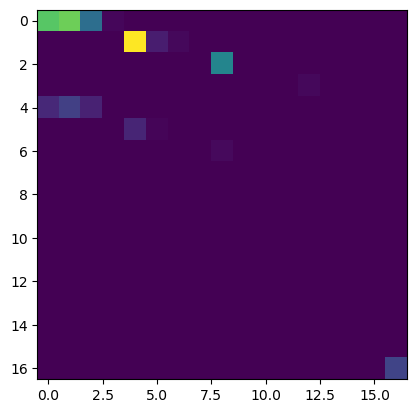

In [116]:
plt.imshow(transition)